In [ ]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


# **EfficientNetB0': EfficientNetB0 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
16705208/16705208 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 1.3004 - accuracy: 0.4722

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 35s 2s/step - loss: 1.3004 - accuracy: 0.4722 - val_loss: 1.1200 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 5s 298ms/step - loss: 0.8064 - accuracy: 0.5211 - val_loss: 0.6958 - val_accuracy: 0.4375
Epoch 3/200
18/18 [==============================] - 5s 297ms/step - loss: 0.7400 - accuracy: 0.4789 - val_loss: 0.7512 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 5s 293ms/step - loss: 0.7468 - accuracy: 0.5352 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/200
18/18 [==============================] - 5s 289ms/step - loss: 0.7453 - accuracy: 0.5352 - val_loss: 0.7468 - val_accuracy: 0.5000
Epoch 6/200
18/18 [==============================] - 5s 294ms/step - loss: 0.7488 - accuracy: 0.5278 - val_loss: 0.7367 - val_accuracy: 0.4375
Epoch 7/200
18/18 [==============================] - 5s 291ms/step - loss: 0.7299 - accuracy: 0.4930 - val_loss: 0.6936 - val_accuracy: 0.5000
Epoch 8/200
1

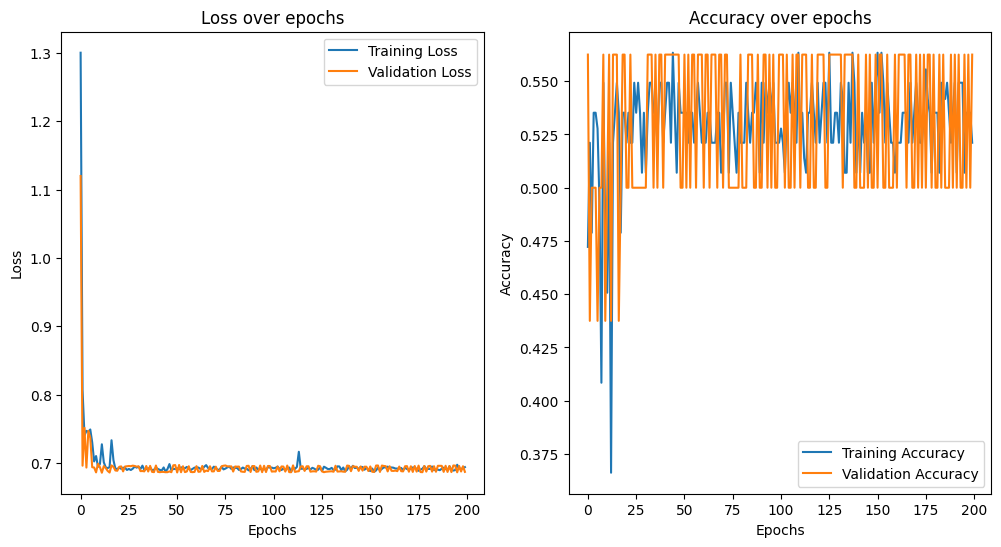

5/5 [==============================] - 2s 183ms/step
Training Loss: 0.6936953067779541
Validation Loss: 0.686760425567627
Training Accuracy: 0.5211267471313477
Validation Accuracy: 0.5625
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.36651583710407243
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.2647058823529412
Macro Recall: 0.5
Macro F1 Score: 0.3461538461538462
Precision (None): [0.         0.52941176]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.69230769]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'EfficientNetB0'
activation = 'relu'
dropout_rate = 0.0
learning_rate = 0.01
epochs = 200

# Build model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **VGG19 200 epoch**


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
80134624/80134624 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 0.7468 - accuracy: 0.4789

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 8s 380ms/step - loss: 0.7468 - accuracy: 0.4789 - val_loss: 0.7592 - val_accuracy: 0.4375
Epoch 2/200
18/18 [==============================] - 7s 399ms/step - loss: 0.7501 - accuracy: 0.4648 - val_loss: 0.7010 - val_accuracy: 0.4375
Epoch 3/200
18/18 [==============================] - 6s 349ms/step - loss: 0.7259 - accuracy: 0.4648 - val_loss: 0.6901 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 7s 367ms/step - loss: 0.7086 - accuracy: 0.4789 - val_loss: 0.7206 - val_accuracy: 0.5000
Epoch 5/200
18/18 [==============================] - 6s 340ms/step - loss: 0.6826 - accuracy: 0.5493 - val_loss: 0.6981 - val_accuracy: 0.4375
Epoch 6/200
18/18 [==============================] - 6s 334ms/step - loss: 0.7376 - accuracy: 0.4930 - val_loss: 0.7700 - val_accuracy: 0.5000
Epoch 7/200
18/18 [==============================] - 6s 346ms/step - loss: 0.7761 - accuracy: 0.3944 - val_loss: 0.7159 - val_accuracy: 0.5625
Epoch 8/200

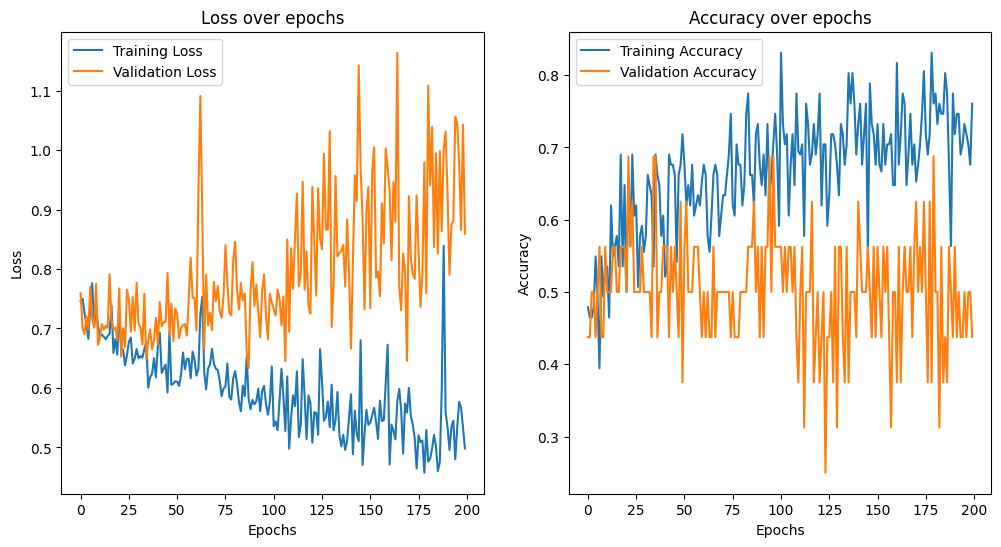

5/5 [==============================] - 1s 219ms/step
Training Loss: 0.49825519323349
Validation Loss: 0.8593533039093018
Training Accuracy: 0.7605633735656738
Validation Accuracy: 0.4375
Weighted Precision: 0.4786096256684492
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.45944272445820433
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.4772727272727273
Macro Recall: 0.47916666666666663
Macro F1 Score: 0.4631578947368421
Precision (None): [0.45454545 0.5       ]
Recall (None): [0.625      0.33333333]
F1 Score (None): [0.52631579 0.4       ]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'VGG19'
activation = 'sigmoid'
dropout_rate = 0.0
learning_rate = 0.001
epochs = 200

# Build model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **Vgg16 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
58889256/58889256 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - 8s 386ms/step - loss: 6.6352 - accuracy: 0.5070 - val_loss: 0.8493 - val_accuracy: 0.5000
Epoch 2/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 6s 323ms/step - loss: 0.7268 - accuracy: 0.4930 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 6s 325ms/step - loss: 0.6932 - accuracy: 0.5634 - val_loss: 0.6998 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 6s 333ms/step - loss: 0.7000 - accuracy: 0.5211 - val_loss: 0.6855 - val_accuracy: 0.5625
Epoch 5/200
18/18 [==============================] - 6s 328ms/step - loss: 0.7066 - accuracy: 0.5634 - val_loss: 0.6966 - val_accuracy: 0.5000
Epoch 6/200
18/18 [==============================] - 6s 323ms/step - loss: 0.7358 - accuracy: 0.5352 - val_loss: 0.6850 - val_accuracy: 0.5625
Epoch 7/200
18/18 [==============================] - 6s 327ms/step - loss: 0.6930 - accuracy: 0.5070 - val_loss: 0.6935 - val_accuracy: 0.4375
Epoch 8/200
18/18 [==============================] - 6s 323ms/step - loss: 0.6949 - accuracy: 0.4225 - val_loss: 0.6891 - val_accuracy: 0.5625
Epoch 9/200

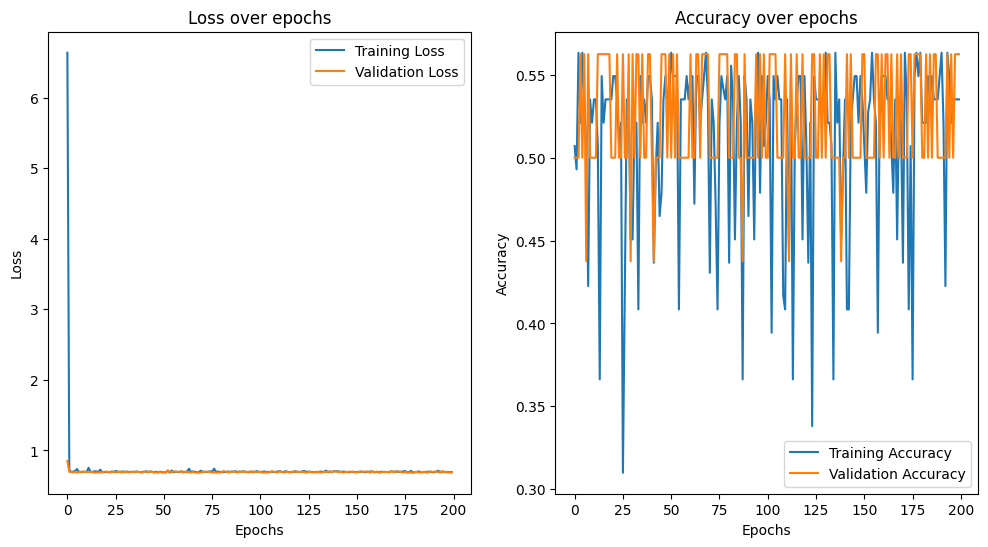

5/5 [==============================] - 1s 212ms/step
Training Loss: 0.6940299868583679
Validation Loss: 0.6871029138565063
Training Accuracy: 0.5352112650871277
Validation Accuracy: 0.5625
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.36651583710407243
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.2647058823529412
Macro Recall: 0.5
Macro F1 Score: 0.3461538461538462
Precision (None): [0.         0.52941176]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.69230769]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'VGG16'
activation = 'relu'
dropout_rate = 0.0
learning_rate = 0.1
epochs = 200

# Build model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **MobileNetV2 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 1.1839 - accuracy: 0.4507

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 9s 361ms/step - loss: 1.1839 - accuracy: 0.4507 - val_loss: 1.2682 - val_accuracy: 0.4375
Epoch 2/200
18/18 [==============================] - 5s 298ms/step - loss: 0.7005 - accuracy: 0.7639 - val_loss: 1.9899 - val_accuracy: 0.5625
Epoch 3/200
18/18 [==============================] - 5s 278ms/step - loss: 1.0954 - accuracy: 0.6056 - val_loss: 1.2933 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 5s 282ms/step - loss: 0.7056 - accuracy: 0.5493 - val_loss: 0.8393 - val_accuracy: 0.5625
Epoch 5/200
18/18 [==============================] - 5s 281ms/step - loss: 0.8086 - accuracy: 0.5634 - val_loss: 1.1250 - val_accuracy: 0.4375
Epoch 6/200
18/18 [==============================] - 5s 280ms/step - loss: 0.5611 - accuracy: 0.7183 - val_loss: 1.0115 - val_accuracy: 0.3750
Epoch 7/200
18/18 [==============================] - 5s 279ms/step - loss: 0.6338 - accuracy: 0.6761 - val_loss: 1.0660 - val_accuracy: 0.3125
Epoch 8/200

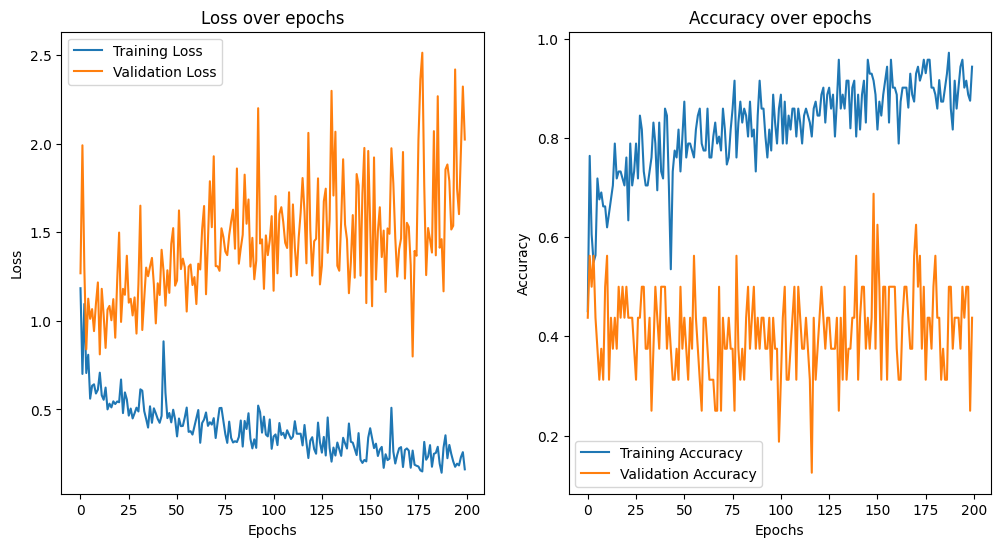

5/5 [==============================] - 2s 184ms/step
Training Loss: 0.16237875819206238
Validation Loss: 2.022545099258423
Training Accuracy: 0.9436619877815247
Validation Accuracy: 0.4375
Weighted Precision: 0.5240641711229946
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.5193277310924369
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.5227272727272727
Macro Recall: 0.5208333333333333
Macro F1 Score: 0.5142857142857142
Precision (None): [0.5        0.54545455]
Recall (None): [0.375      0.66666667]
F1 Score (None): [0.42857143 0.6       ]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'MobileNetV2'
activation = 'relu'
dropout_rate = 0.2
learning_rate = 0.001
epochs = 200

# Build model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **'NASNetMobile 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
19993432/19993432 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 67.8248 - accuracy: 0.6479

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 22s 603ms/step - loss: 67.8248 - accuracy: 0.6479 - val_loss: 107.7362 - val_accuracy: 0.4375
Epoch 2/200
18/18 [==============================] - 6s 338ms/step - loss: 50.4102 - accuracy: 0.4085 - val_loss: 64.1969 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 5s 291ms/step - loss: 8.9578 - accuracy: 0.4225 - val_loss: 1.6468 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 5s 289ms/step - loss: 0.9341 - accuracy: 0.5915 - val_loss: 0.8469 - val_accuracy: 0.4375
Epoch 5/200
18/18 [==============================] - 5s 292ms/step - loss: 0.8289 - accuracy: 0.5352 - val_loss: 0.7053 - val_accuracy: 0.3750
Epoch 6/200
18/18 [==============================] - 5s 284ms/step - loss: 0.6777 - accuracy: 0.5352 - val_loss: 0.6833 - val_accuracy: 0.5000
Epoch 7/200
18/18 [==============================] - 6s 341ms/step - loss: 0.7334 - accuracy: 0.6479 - val_loss: 0.6711 - val_accuracy: 0.5625
Epoch

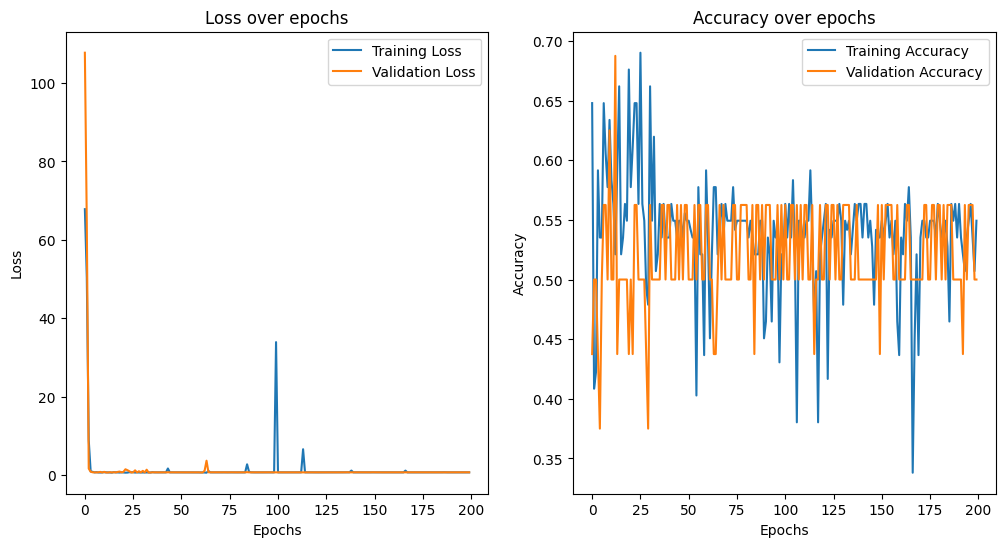

5/5 [==============================] - 5s 188ms/step
Training Loss: 0.6811277866363525
Validation Loss: 0.7005663514137268
Training Accuracy: 0.5492957830429077
Validation Accuracy: 0.5
Weighted Precision: 0.5294117647058824
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.5294117647058824
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.5277777777777778
Macro Recall: 0.5277777777777778
Macro F1 Score: 0.5277777777777778
Precision (None): [0.5        0.55555556]
Recall (None): [0.5        0.55555556]
F1 Score (None): [0.5        0.55555556]


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'NASNetMobile'
activation = 'relu'
dropout_rate = 0.1
learning_rate = 0.1
epochs = 200

# Build model
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
